In [2]:
import random
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from collections import Counter


bosch distr

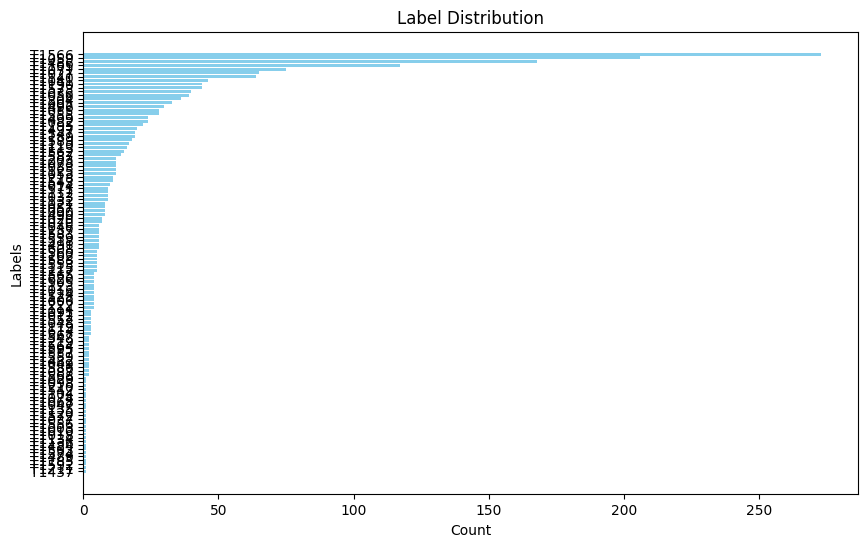

Label: T1566, Count: 273
Label: T1059, Count: 206
Label: T1486, Count: 168
Label: T1105, Count: 117
Label: T1071, Count: 75
Label: T1027, Count: 65
Label: T1140, Count: 64
Label: T1041, Count: 46
Label: T1190, Count: 44
Label: T1573, Count: 44
Label: T1036, Count: 40
Label: T1056, Count: 39
Label: T1204, Count: 36
Label: T1005, Count: 33
Label: T1496, Count: 30
Label: T1055, Count: 28
Label: T1555, Count: 28
Label: T1499, Count: 24
Label: T1082, Count: 24
Label: T1195, Count: 22
Label: T1497, Count: 20
Label: T1547, Count: 19
Label: T1189, Count: 19
Label: T1589, Count: 18
Label: T1110, Count: 17
Label: T1113, Count: 16
Label: T1562, Count: 15
Label: T1587, Count: 14
Label: T1203, Count: 12
Label: T1078, Count: 12
Label: T1083, Count: 12
Label: T1125, Count: 12
Label: T1053, Count: 12
Label: T1218, Count: 11
Label: T1543, Count: 11
Label: T1014, Count: 10
Label: T1571, Count: 9
Label: T1112, Count: 9
Label: T1033, Count: 9
Label: T1132, Count: 9
Label: T1021, Count: 8
Label: T1057, Cou

In [5]:
# Load the JSON data
with open('/home/simonettos/thijs/classification/classification/datasets/bosch_train.json', 'r') as f:
    data = json.load(f)

# Initialize an empty dictionary to hold label counts
label_counts = {}

# Iterate through the items and count the labels
for key, label_list in data['labels'].items():  # 'labels' field contains the dictionary
    for label in label_list:
        if not label.startswith('T1') or label.startswith('TA'):
            continue
        if label in label_counts:
            label_counts[label] += 1
        else:
            label_counts[label] = 1

# Sort the labels by the count (descending)
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

# Extract labels and their counts for plotting
labels = [item[0] for item in sorted_labels]
counts = [item[1] for item in sorted_labels]

# Plot the label distribution
plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='skyblue')
plt.xlabel('Count')
plt.ylabel('Labels')
plt.title('Label Distribution')
plt.gca().invert_yaxis()  # To display the highest count at the top
plt.show()
# Print the label counts 
for label, count in zip(labels, counts): 
    print(f'Label: {label}, Count: {count}') 
print("number of labels:", len(label_counts) )



Tram distr

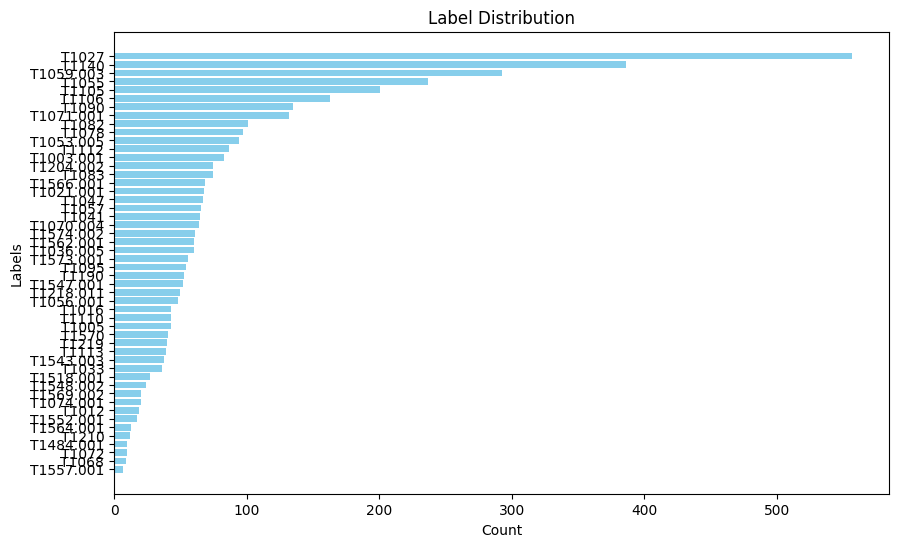

Label: T1027, Count: 557
Label: T1140, Count: 386
Label: T1059.003, Count: 293
Label: T1055, Count: 237
Label: T1105, Count: 201
Label: T1106, Count: 163
Label: T1090, Count: 135
Label: T1071.001, Count: 132
Label: T1082, Count: 101
Label: T1078, Count: 97
Label: T1053.005, Count: 94
Label: T1112, Count: 87
Label: T1003.001, Count: 83
Label: T1204.002, Count: 75
Label: T1083, Count: 75
Label: T1566.001, Count: 69
Label: T1021.001, Count: 68
Label: T1047, Count: 67
Label: T1057, Count: 66
Label: T1041, Count: 65
Label: T1070.004, Count: 64
Label: T1574.002, Count: 61
Label: T1562.001, Count: 60
Label: T1036.005, Count: 60
Label: T1573.001, Count: 56
Label: T1095, Count: 54
Label: T1190, Count: 53
Label: T1547.001, Count: 52
Label: T1218.011, Count: 50
Label: T1056.001, Count: 48
Label: T1016, Count: 43
Label: T1110, Count: 43
Label: T1005, Count: 43
Label: T1570, Count: 41
Label: T1219, Count: 40
Label: T1113, Count: 39
Label: T1543.003, Count: 38
Label: T1033, Count: 36
Label: T1518.00

In [18]:
with open('/home/simonettos/thijs/classification/classification/datasets/tram_train.json', 'r') as f:
    data = json.load(f)

# Initialize an empty dictionary to hold label counts
label_counts = {}

# Iterate through the items and count the labels
for key, label_list in data['labels'].items():  # 'labels' field contains the dictionary
    for label in label_list:
        if not label.startswith('T1') or label.startswith('TA'):
            continue
        if label in label_counts:
            label_counts[label] += 1
        else:
            label_counts[label] = 1

# Sort the labels by the count (descending)
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

# Extract labels and their counts for plotting
labels = [item[0] for item in sorted_labels]
counts = [item[1] for item in sorted_labels]

# Plot the label distribution
plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='skyblue')
plt.xlabel('Count')
plt.ylabel('Labels')
plt.title('Label Distribution')
plt.gca().invert_yaxis()  # To display the highest count at the top
plt.show()
# Print the label counts 
for label, count in zip(labels, counts): 
    print(f'Label: {label}, Count: {count}') 
print("number of labels:", len(label_counts) )



Functs


In [9]:
PREFIXES = ("T1")
import pandas as pd
from collections import Counter



def ensure_labels_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensures df has a 'labels' column where each row is a list of labels.
    Supports common read_json shapes:
    - record style: df has 'labels' column already
    - dict style: json is {"labels": {id: [...]}} resulting df where 'labels' may be in index/columns
    """
    if "labels" in df.columns:
        # normalize: ensure list
        df = df.copy()
        df["labels"] = df["labels"].apply(lambda x: x if isinstance(x, list) else ([] if pd.isna(x) else list(x)))
        return df

    # Handle dict-style JSON: {"labels": {id: [...]}}
    # pd.read_json often yields a DF where the key "labels" becomes a column OR an index entry
    if "labels" in df.index:
        # df.loc["labels"] is a Series (columns -> values) containing the dict, sometimes nested
        row = df.loc["labels"]
        # if it's a Series of length 1 containing the dict
        if isinstance(row, pd.Series) and len(row) == 1 and isinstance(row.iloc[0], dict):
            labels_dict = row.iloc[0]
        elif isinstance(row, dict):
            labels_dict = row
        else:
            # sometimes row is a Series where each element is itself dict-ish; try to merge
            # best-effort fallback
            possible = row.to_dict()
            # unwrap one layer if needed
            if len(possible) == 1 and isinstance(next(iter(possible.values())), dict):
                labels_dict = next(iter(possible.values()))
            else:
                labels_dict = possible

        out = pd.DataFrame({
            "doc_id": list(labels_dict.keys()),
            "labels": list(labels_dict.values())
        })
        out["labels"] = out["labels"].apply(lambda x: x if isinstance(x, list) else list(x))
        return out

    raise ValueError("Could not locate labels. Check df.columns and df.index after read_json().")

def filter_labels_df(df: pd.DataFrame, prefixes=PREFIXES) -> pd.DataFrame:
    df = df.copy()
    df["labels"] = df["labels"].apply(
        lambda labs: [l for l in labs if isinstance(l, str) and l.startswith(prefixes)]
    )
    return df

def count_labels_df(df: pd.DataFrame) -> Counter:
    c = Counter()
    for labs in df["labels"]:
        c.update(labs)
    return c

def filter_labels_list(labels, prefixes=PREFIXES):
    if not isinstance(labels, list):
        return []
    return [l for l in labels if isinstance(l, str) and l.startswith(prefixes)]

def count_labels_from_df(df, label_col="labels"):
    c = Counter()
    for labs in df[label_col]:
        if isinstance(labs, list):
            c.update(labs)
    return c

def augment_till_max(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    prefixes=PREFIXES,
    seed=None,
) -> tuple[pd.DataFrame, Counter]:
    """
    For each label in df2, if df1 count < max_count_df1, sample rows from df2 that contain that label
    and append them to df1 until that label surpasses max_count_df1 (or df2 runs out).
    Returns augmented df1 and final counts.
    """
    rng = random.Random(seed)

    df1 = filter_labels_df(df1, prefixes)
    df2 = filter_labels_df(df2, prefixes)

    counts1 = count_labels_df(df1)
    counts2 = count_labels_df(df2)

    if not counts1:
        raise ValueError("df1 has no labels after filtering. Check prefixes or data format.")

    max_count_df1 = max(counts1.values())

    # Precompute which rows in df2 contain each label (fast lookup)
    # Build a mapping label -> list of row indices in df2 that contain it
    label_to_indices = {}
    for idx, labs in df2["labels"].items():
        for l in labs:
            label_to_indices.setdefault(l, []).append(idx)

    rows_to_add = []

    for label in counts2.keys():
        current = counts1.get(label, 0)
        if current >= max_count_df1:
            continue

        needed = (max_count_df1 - current)
        candidate_indices = label_to_indices.get(label, [])
        if not candidate_indices:
            continue

        # sample without replacement
        k = min(needed, len(candidate_indices))
        sampled = rng.sample(candidate_indices, k)
        rows_to_add.extend(sampled)

        # Update counts1 incrementally to reduce oversampling across labels
        for idx in sampled:
            counts1.update(df2.at[idx, "labels"])

        # Update max_count_df1? In your original logic you kept it fixed as original max.
        # We'll keep it fixed to match your previous behavior.

    if rows_to_add:
        df_added = df2.loc[rows_to_add].copy()
        df_aug = pd.concat([df1, df_added], ignore_index=True)
    else:
        df_aug = df1.copy()

    final_counts = count_labels_df(df_aug)
    return df_aug, final_counts


def augment_add_fraction_of_max(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    add_fraction_of_max: float = 0.30,
    prefixes=PREFIXES,
    seed=None,
    max_passes: int = 10,
) -> tuple[pd.DataFrame, Counter]:
    """
    For every label present in df1 (after filtering), try to ADD at least:
        delta = ceil(add_fraction_of_max * max_count_df1)
    more occurrences, by sampling rows from df2 (without replacement).

    Multi-label-aware:
    - A sampled row can contribute to multiple labels at once.
    - Each df2 row is added at most once globally (no duplicates).

    "When possible":
    - If df2 doesn't contain enough candidate rows for some label, we add as many as possible.

    Strategy:
    - Precompute label -> candidate df2 indices.
    - Maintain remaining_needed[label] = delta (how many more occurrences we want to add for that label).
    - Greedy multi-pass sampling: repeatedly prioritize labels with the highest remaining need.

    Returns:
      (augmented_df, final_label_counts)
    """
    if not (0 < add_fraction_of_max <= 1.0):
        raise ValueError("add_fraction_of_max must be in (0, 1].")

    rng = random.Random(seed)

    # Filter labels
    df1 = filter_labels_df(df1, prefixes)
    df2 = filter_labels_df(df2, prefixes)

    # Counts in df1
    counts1 = count_labels_df(df1)
    if not counts1:
        raise ValueError("df1 has no labels after filtering. Check prefixes or data format.")

    max_count_df1 = max(counts1.values())
    delta = int(math.ceil(max_count_df1 * add_fraction_of_max))

    # Labels we will try to boost (labels already present in df1)
    labels_to_boost = list(counts1.keys())

    # remaining_needed: we want +delta occurrences for each label (not a final target)
    remaining_needed = {lbl: delta for lbl in labels_to_boost}

    # Precompute label -> list of df2 row indices containing it
    label_to_indices: dict[str, list] = {}
    for idx, labs in df2["labels"].items():
        for l in labs:
            if l in remaining_needed:  # only store for labels we care about
                label_to_indices.setdefault(l, []).append(idx)

    used_indices: set = set()
    rows_to_add: list = []

    # Helper: apply a chosen df2 row, decreasing needs for any labels it contains
    def apply_row(idx):
        labs = df2.at[idx, "labels"]
        for l in labs:
            if l in remaining_needed and remaining_needed[l] > 0:
                remaining_needed[l] -= 1

    # Multi-pass greedy:
    # each pass: iterate labels in order of most remaining need, pick rows for them
    for _pass in range(max_passes):
        progress = 0

        # labels still needing boosts, sorted by remaining need desc
        active_labels = [l for l, need in remaining_needed.items() if need > 0]
        if not active_labels:
            break

        active_labels.sort(key=lambda l: remaining_needed[l], reverse=True)

        for label in active_labels:
            need = remaining_needed[label]
            if need <= 0:
                continue

            candidates = label_to_indices.get(label, [])
            if not candidates:
                continue

            # only unused candidates
            available = [i for i in candidates if i not in used_indices]
            if not available:
                continue

            # sample up to "need" rows for this label
            k = min(need, len(available))
            sampled = rng.sample(available, k)

            for idx in sampled:
                used_indices.add(idx)
                rows_to_add.append(idx)
                apply_row(idx)
                progress += 1

        # If we couldn't add anything in this pass, no further progress is possible
        if progress == 0:
            break

    if rows_to_add:
        df_added = df2.loc[rows_to_add].copy()
        df_aug = pd.concat([df1, df_added], ignore_index=True)
    else:
        df_aug = df1.copy()

    final_counts = count_labels_df(df_aug)
    return df_aug, final_counts



def augment_performance_driven(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    perf_df: pd.DataFrame,
    prefixes=PREFIXES,
    seed=None,
    # ---- how many rows to add overall ----
    total_budget=None,   # if None -> computed from fraction_of_df1
    fraction_of_df1: float = 0.30,     # used when total_budget=None
    # ---- what "weakness" means ----
    score_mode: str = "fnr",           # "fnr", "low_f1", "low_recall", "combo"
    f1_col: str = "f1",
    # ---- guards ----
    min_support: int = 0,              # ignore labels with (TP+FN) < min_support in perf_df
    max_per_label_add= None,  # cap to avoid runaway
) -> tuple[pd.DataFrame, Counter, pd.DataFrame]:
    """
    Performance-driven augmentation: allocate more df2 samples to labels where the model is weak.

    perf_df must have columns: ["label","TP","FP","FN","TN"].
    Optionally, if score_mode="low_f1", it should have an f1 column (or provide f1_col).

    Parameters
    ----------
    total_budget:
        Total number of df2 rows to add. If None, uses fraction_of_df1 * len(df1).
    fraction_of_df1:
        Used only if total_budget=None.
    score_mode:
        - "fnr": prioritize high false-negative-rate (FN/(TP+FN))  => recall weakness
        - "low_recall": same as fnr
        - "low_f1": prioritize low F1
        - "combo": 0.6*FNR + 0.4*(1-F1) (requires f1)
    max_per_label_add:
        Optional cap per label (in terms of how many rows we attempt to sample for that label).
    Returns
    -------
    df_aug, final_counts, allocation_df
    """
    rng = random.Random(seed)

    # Filter labels
    df1 = filter_labels_df(df1, prefixes)
    df2 = filter_labels_df(df2, prefixes)

    counts1 = count_labels_df(df1)
    if not counts1:
        raise ValueError("df1 has no labels after filtering. Check prefixes or data format.")

    # Budget
    if total_budget is None:
        total_budget = int(math.ceil(fraction_of_df1 * len(df1)))
    total_budget = max(0, int(total_budget))

    # --- build label -> candidate indices in df2 ---
    label_to_indices: dict[str, list] = {}
    for idx, labs in df2["labels"].items():
        for l in labs:
            label_to_indices.setdefault(l, []).append(idx)

    # --- compute weakness score per label from perf_df ---
    pdf = perf_df.copy()

    # Ensure required columns
    for col in ["label", "TP", "FP", "FN", "TN"]:
        if col not in pdf.columns:
            raise ValueError(f"perf_df missing required column: {col}")

    # Support = positives in truth
    pdf["support"] = pdf["TP"] + pdf["FN"]

    # Ignore tiny support labels (optional)
    pdf = pdf[pdf["support"] >= min_support].copy()

    # Compute recall + FNR
    pdf["recall"] = pdf["TP"] / (pdf["TP"] + pdf["FN"] + 1e-12)
    pdf["fnr"]    = pdf["FN"] / (pdf["TP"] + pdf["FN"] + 1e-12)

    if score_mode in ("low_f1", "combo") and f1_col not in pdf.columns:
        raise ValueError(f"score_mode='{score_mode}' requires perf_df column '{f1_col}'")

    if score_mode in ("fnr", "low_recall"):
        pdf["score"] = pdf["fnr"]
    elif score_mode == "low_f1":
        pdf["score"] = 1.0 - pdf[f1_col].clip(0, 1)
    elif score_mode == "combo":
        pdf["score"] = 0.6 * pdf["fnr"] + 0.4 * (1.0 - pdf[f1_col].clip(0, 1))
    else:
        raise ValueError("score_mode must be one of: 'fnr','low_recall','low_f1','combo'")

    # Only augment labels that exist in df1 (common practice)
    pdf = pdf[pdf["label"].isin(counts1.keys())].copy()

    # If nothing to do
    if pdf.empty or total_budget == 0:
        final_counts = count_labels_df(df1)
        alloc_df = pdf.assign(allocated=0, available=0)
        return df1.copy(), final_counts, alloc_df

    # Make sure we only allocate to labels that have candidates in df2
    pdf["available"] = pdf["label"].apply(lambda l: len(label_to_indices.get(l, [])))
    pdf = pdf[pdf["available"] > 0].copy()

    if pdf.empty:
        final_counts = count_labels_df(df1)
        alloc_df = perf_df.copy()
        alloc_df["allocated"] = 0
        alloc_df["available"] = 0
        return df1.copy(), final_counts, alloc_df

    # Normalize scores into allocation weights
    pdf["score"] = pdf["score"].clip(lower=0)
    score_sum = float(pdf["score"].sum())

    if score_sum == 0.0:
        # All scores are zero -> distribute uniformly across candidate labels
        pdf["weight"] = 1.0 / len(pdf)
    else:
        pdf["weight"] = pdf["score"] / score_sum

    # Initial allocation (rounded)
    pdf["allocated"] = (pdf["weight"] * total_budget).round().astype(int)

    # Ensure at least 1 for labels with nonzero score (optional)
    # pdf.loc[pdf["score"] > 0, "allocated"] = pdf.loc[pdf["score"] > 0, "allocated"].clip(lower=1)

    # Apply caps: availability and max_per_label_add
    if max_per_label_add is not None:
        pdf["allocated"] = pdf["allocated"].clip(upper=int(max_per_label_add))
    pdf["allocated"] = pdf[["allocated", "available"]].min(axis=1).astype(int)

    # Fix rounding drift to match total_budget as best as possible
    allocated_sum = int(pdf["allocated"].sum())
    remaining = total_budget - allocated_sum

    if remaining > 0:
        # Greedily give extra to highest-score labels with remaining availability
        pdf = pdf.sort_values("score", ascending=False).copy()
        i = 0
        while remaining > 0 and i < len(pdf):
            cap = pdf.iloc[i]["available"] - pdf.iloc[i]["allocated"]
            if max_per_label_add is not None:
                cap = min(cap, int(max_per_label_add) - int(pdf.iloc[i]["allocated"]))
            if cap > 0:
                add = min(int(cap), remaining)
                pdf.iat[i, pdf.columns.get_loc("allocated")] += add
                remaining -= add
            i += 1

    # --- sample rows according to allocation ---
    used_indices: set = set()
    rows_to_add: list = []

    # Iterate labels from highest score down (so we “spend” budget on worst labels first)
    pdf = pdf.sort_values("score", ascending=False).copy()

    for _, row in pdf.iterrows():
        label = row["label"]
        need = int(row["allocated"])
        if need <= 0:
            continue

        candidates = label_to_indices.get(label, [])
        if not candidates:
            continue

        # only unused
        available = [idx for idx in candidates if idx not in used_indices]
        if not available:
            continue

        k = min(need, len(available))
        sampled = rng.sample(available, k)

        rows_to_add.extend(sampled)
        used_indices.update(sampled)

        # Update counts1 so multi-label rows reduce future oversampling effects
        for idx in sampled:
            counts1.update(df2.at[idx, "labels"])

    # Build augmented dataframe
    if rows_to_add:
        df_added = df2.loc[rows_to_add].copy()
        df_aug = pd.concat([df1, df_added], ignore_index=True)
    else:
        df_aug = df1.copy()

    final_counts = count_labels_df(df_aug)
    allocation_df = pdf[["label", "TP", "FP", "FN", "TN", "support", "recall", "fnr", "score", "available", "allocated"]].copy()

    return df_aug, final_counts, allocation_df


TRAM

In [10]:

from sklearn.model_selection import train_test_split


df_train_orig = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/tram_train.json")
df_train_augm = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/tram_train_augmented_mitre.json")
df_train_orig, df_val = train_test_split(df_train_orig, test_size=0.2, random_state=42)
data1 = ensure_labels_column(df_train_orig)
data2 = ensure_labels_column(df_train_augm)


# aug_df, final_label_counts = augment_till_max(data1, data2, prefixes=PREFIXES, seed=None)
aug_df, final_label_counts = augment_add_fraction_of_max(data1, data2, prefixes=PREFIXES, seed=None)

# cm_all_df = pd.read_csv("/home/simonettos/thijs/classification/classification/extra/all_docs_cm_tram.csv")
# perf_df = (cm_all_df.groupby("label")[["TP", "FP", "FN", "TN"]].sum().reset_index())
# eps = 1e-12
# perf_df["precision"] = perf_df["TP"] / (perf_df["TP"] + perf_df["FP"] + eps)
# perf_df["recall"]    = perf_df["TP"] / (perf_df["TP"] + perf_df["FN"] + eps)
# perf_df["f1"]        = 2 * perf_df["precision"] * perf_df["recall"] / (perf_df["precision"] + perf_df["recall"] + eps)
# print("Worst by recall:")
# print(perf_df.sort_values("recall").head(50)[["label","TP","FP","FN","precision","recall","f1"]])
# print("\nWorst by f1:")
# print(perf_df.sort_values("f1").head(50)[["label","TP","FP","FN","precision","recall","f1"]])

# fraction_of_df1 = 0.30
# total_budget = int(math.ceil(fraction_of_df1 * len(data1)))

# aug_df, final_counts, allocation_df = augment_performance_driven(
#     df1=data1,
#     df2=data2,
#     perf_df=perf_df,          # computed on held-out validation (or CV) split
#     prefixes=PREFIXES,
#     seed=None,
#     total_budget=total_budget,
#     score_mode="fnr",       # more stable than pure FNR
#     min_support=1,           # stabilize per-label weakness estimates
#     max_per_label_add=math.ceil(0.3 * total_budget),  # cap by budget share
# )

# print(allocation_df.head(30))
print("Original rows:", len(data1))
print("Augmented rows:", len(aug_df))
print("Added rows:", len(aug_df) - len(data1))
print("augmented examples:", aug_df.tail(20))
print("Percentage of augmented data:", (len(aug_df) - len(data1)) / len(data1) * 100, "%")
# Save as pandas-friendly formats
aug_df.to_json(
    "/home/simonettos/thijs/classification/classification/datasets/tram_train_final_mitre.json",
    orient="records",
    indent=2
)

# --- Make sure labels are filtered in each DF ---
data1_filtered = data1.copy()
data1_filtered["labels"] = data1_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

data2_filtered = data2.copy()
data2_filtered["labels"] = data2_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# Example: aug_df is the final combined dataset after you appended sampled rows
aug_df_filtered = aug_df.copy()
aug_df_filtered["labels"] = aug_df_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Counters used by the plot ---
label_counts_data1 = count_labels_from_df(data1_filtered)
label_counts_data2 = count_labels_from_df(data2_filtered)
final_label_counts  = count_labels_from_df(aug_df_filtered)

# Sorted labels based on FINAL distribution
sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]
print ("Original label counter:", label_counts_data1)
print ("Augmented label counter:", label_counts_data2)
print ("Final label counter:", final_label_counts)
print(len(label_counts_data1))
print(len(label_counts_data2))
print(f"Training set size after augmentation: {len(aug_df)} samples")
print(f"Validation set size: {len(df_val)} samples")



Original rows: 12286
Augmented rows: 17333
Added rows: 5047
augmented examples:                                                 sentence   labels  \
17313  APT28 exploited a Windows SMB Remote Code Exec...  [T1210]   
17314  Security applications that look for behavior u...  [T1210]   
17315  Flame can use MS10-061 to exploit a print spoo...  [T1210]   
17316  PoshC2 contains a module for exploiting SMB vi...  [T1210]   
17317  QakBot can move laterally using worm-like func...  [T1210]   
17318  Tonto Team has used EternalBlue exploits for l...  [T1210]   
17319  Dragonfly has exploited a Windows Netlogon vul...  [T1210]   
17320  Ember Bear has used exploits for vulnerabiliti...  [T1210]   
17321  Segment networks and systems appropriately to ...  [T1210]   
17322  Conficker exploited the MS08-067 Windows vulne...  [T1210]   
17323  Lucifer can exploit multiple vulnerabilities i...  [T1210]   
17324  Stuxnet propagates using the MS10-061 Print Sp...  [T1210]   
17325  Adversaries may 

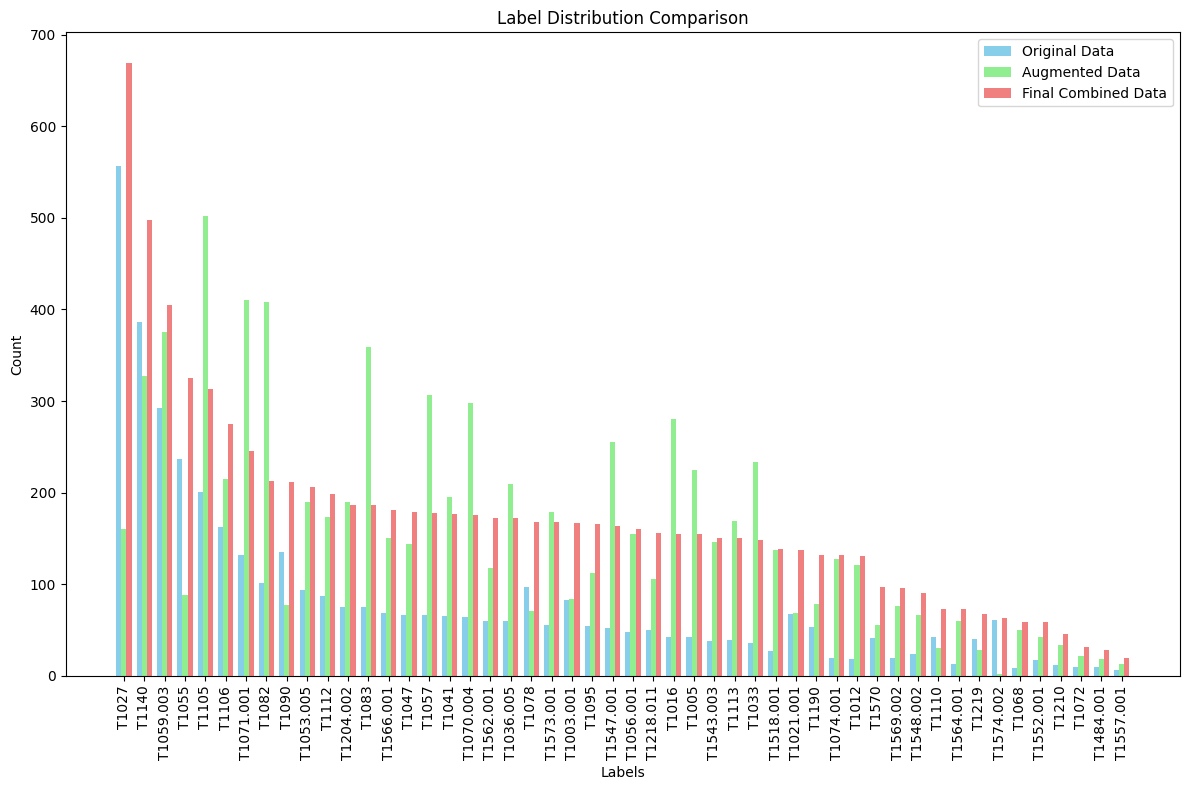

In [41]:


sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]

# Split the labels into the top 10 and the last 10 labels
top_10_labels = sorted_final_labels_labels[:10]
bottom_10_labels = sorted_final_labels_labels[-10:]

sorted_labels_labels = [item for item in sorted_final_labels_labels]
sorted_counts_data1 = [label_counts_data1.get(label, 0) for label in sorted_final_labels_labels]
sorted_counts_data2 = [label_counts_data2.get(label, 0) for label in sorted_final_labels_labels]
sorted_counts_final = [final_label_counts.get(label, 0) for label in sorted_final_labels_labels]

# Create subplots to compare the distributions (vertical bars)
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.25  # Width of the bars
index = range(len(sorted_labels_labels))  # Position of the bars

ax.bar(index, sorted_counts_data1, bar_width, label='Original Data', color='skyblue')
ax.bar([i + bar_width for i in index], sorted_counts_data2, bar_width, label='Augmented Data', color='lightgreen')
ax.bar([i + 2 * bar_width for i in index], sorted_counts_final, bar_width, label='Final Combined Data', color='lightcoral')

ax.set_ylabel('Count')
ax.set_xlabel('Labels')
ax.set_title('Label Distribution Comparison')
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(sorted_labels_labels, rotation=90)  # Rotate labels for better readability
ax.legend()

plt.tight_layout()
plt.show()



Bosch

In [12]:



df_train_orig = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/bosch_train.json")
df_train_augm = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/bosch_train_augmented_mitre.json")
df_train_orig, df_val = train_test_split(df_train_orig, test_size=0.2, random_state=42)
data1 = ensure_labels_column(df_train_orig)
data2 = ensure_labels_column(df_train_augm)

# aug_df, final_label_counts = augment_till_max(data1, data2, prefixes=PREFIXES, seed=None)
aug_df, final_label_counts = augment_add_fraction_of_max(data1, data2, prefixes=PREFIXES, seed=None)

# cm_all_df = pd.read_csv("/home/simonettos/thijs/classification/classification/extra/all_docs_cm_bosch.csv")
# perf_df = (cm_all_df.groupby("label")[["TP", "FP", "FN", "TN"]].sum().reset_index())
# eps = 1e-12
# perf_df["precision"] = perf_df["TP"] / (perf_df["TP"] + perf_df["FP"] + eps)
# perf_df["recall"]    = perf_df["TP"] / (perf_df["TP"] + perf_df["FN"] + eps)
# perf_df["f1"]        = 2 * perf_df["precision"] * perf_df["recall"] / (perf_df["precision"] + perf_df["recall"] + eps)
# print("Worst by recall:")
# print(perf_df.sort_values("recall").head(60)[["label","TP","FP","FN","precision","recall","f1"]])
# print("\nWorst by f1:")
# print(perf_df.sort_values("f1").head(50)[["label","TP","FP","FN","precision","recall","f1"]])

# fraction_of_df1 = 0.30
# total_budget = int(math.ceil(fraction_of_df1 * len(data1)))

# aug_df, final_counts, allocation_df = augment_performance_driven(
#     df1=data1,
#     df2=data2,
#     perf_df=perf_df,          # computed on held-out validation (or CV) split
#     prefixes=PREFIXES,
#     seed=None,
#     total_budget=total_budget,
#     score_mode="fnr",       # more stable than pure FNR
#     min_support=1,           # stabilize per-label weakness estimates
#     max_per_label_add=math.ceil(0.3 * total_budget),  # cap by budget share
# )
print("Final Label Counts after Augmentation:", final_label_counts)
print("Original rows:", len(data1))
print("Augmented rows:", len(aug_df))
print("Added rows:", len(aug_df) - len(data1))
print("augmented examples:\n", aug_df.tail(20))
print("Augmented rows:", len(aug_df))
print("Percentage of augmented data:", (len(aug_df) - len(data1)) / len(data1) * 100, "%")

# Save as pandas-friendly formats
aug_df.to_json(
    "/home/simonettos/thijs/classification/classification/datasets/bosch_train_final_mitre.json",
    orient="records",
    indent=2
)
from collections import Counter

PREFIXES = ("T1")

def filter_labels_list(labels, prefixes=PREFIXES):
    if not isinstance(labels, list):
        return []
    return [l for l in labels if isinstance(l, str) and l.startswith(prefixes)]

def count_labels_from_df(df, label_col="labels"):
    c = Counter()
    for labs in df[label_col]:
        if isinstance(labs, list):
            c.update(labs)
    return c

# --- Make sure labels are filtered in each DF ---
data1_filtered = data1.copy()
data1_filtered["labels"] = data1_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

data2_filtered = data2.copy()
data2_filtered["labels"] = data2_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Your concatenated/augmented DF (use whatever you named it) ---
# Example: aug_df is the final combined dataset after you appended sampled rows
aug_df_filtered = aug_df.copy()
aug_df_filtered["labels"] = aug_df_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Counters used by the plot ---
label_counts_data1 = count_labels_from_df(data1_filtered)
label_counts_data2 = count_labels_from_df(data2_filtered)
final_label_counts  = count_labels_from_df(aug_df_filtered)

# Sorted labels based on FINAL distribution
sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]
print ("Original label counter:", label_counts_data1)
print ("Augmented label counter:", label_counts_data2)
print ("Final label counter:", final_label_counts)
print(len(label_counts_data1))
print(len(label_counts_data2))
#labels not in the augmentation dataset but in the original
labels_not_in_aug = [lbl for lbl in label_counts_data1 if lbl not in label_counts_data2]
print("Labels in original but not in augmented:", labels_not_in_aug)


Final Label Counts after Augmentation: Counter({'T1566': 244, 'T1059': 218, 'T1486': 210, 'T1105': 158, 'T1027': 122, 'T1140': 119, 'T1041': 110, 'T1190': 103, 'T1005': 100, 'T1036': 99, 'T1055': 90, 'T1082': 87, 'T1071': 80, 'T1113': 80, 'T1078': 77, 'T1083': 76, 'T1203': 75, 'T1112': 75, 'T1090': 74, 'T1033': 74, 'T1571': 73, 'T1057': 73, 'T1046': 72, 'T1016': 71, 'T1124': 71, 'T1119': 70, 'T1012': 70, 'T1049': 69, 'T1018': 69, 'T1047': 69, 'T1490': 68, 'T1555': 67, 'T1189': 66, 'T1560': 61, 'T1489': 58, 'T1573': 56, 'T1518': 56, 'T1102': 53, 'T1068': 51, 'T1115': 50, 'T1125': 47, 'T1056': 46, 'T1110': 45, 'T1204': 43, 'T1497': 43, 'T1572': 43, 'T1070': 42, 'T1014': 42, 'T1539': 41, 'T1010': 38, 'T1020': 37, 'T1123': 37, 'T1482': 37, 'T1091': 36, 'T1210': 35, 'T1217': 34, 'T1620': 33, 'T1195': 32, 'T1589': 30, 'T1543': 30, 'T1219': 30, 'T1134': 30, 'T1496': 29, 'T1562': 27, 'T1614': 26, 'T1559': 26, 'T1568': 26, 'T1499': 25, 'T1547': 24, 'T1021': 23, 'T1574': 23, 'T1185': 21, 'T1567'

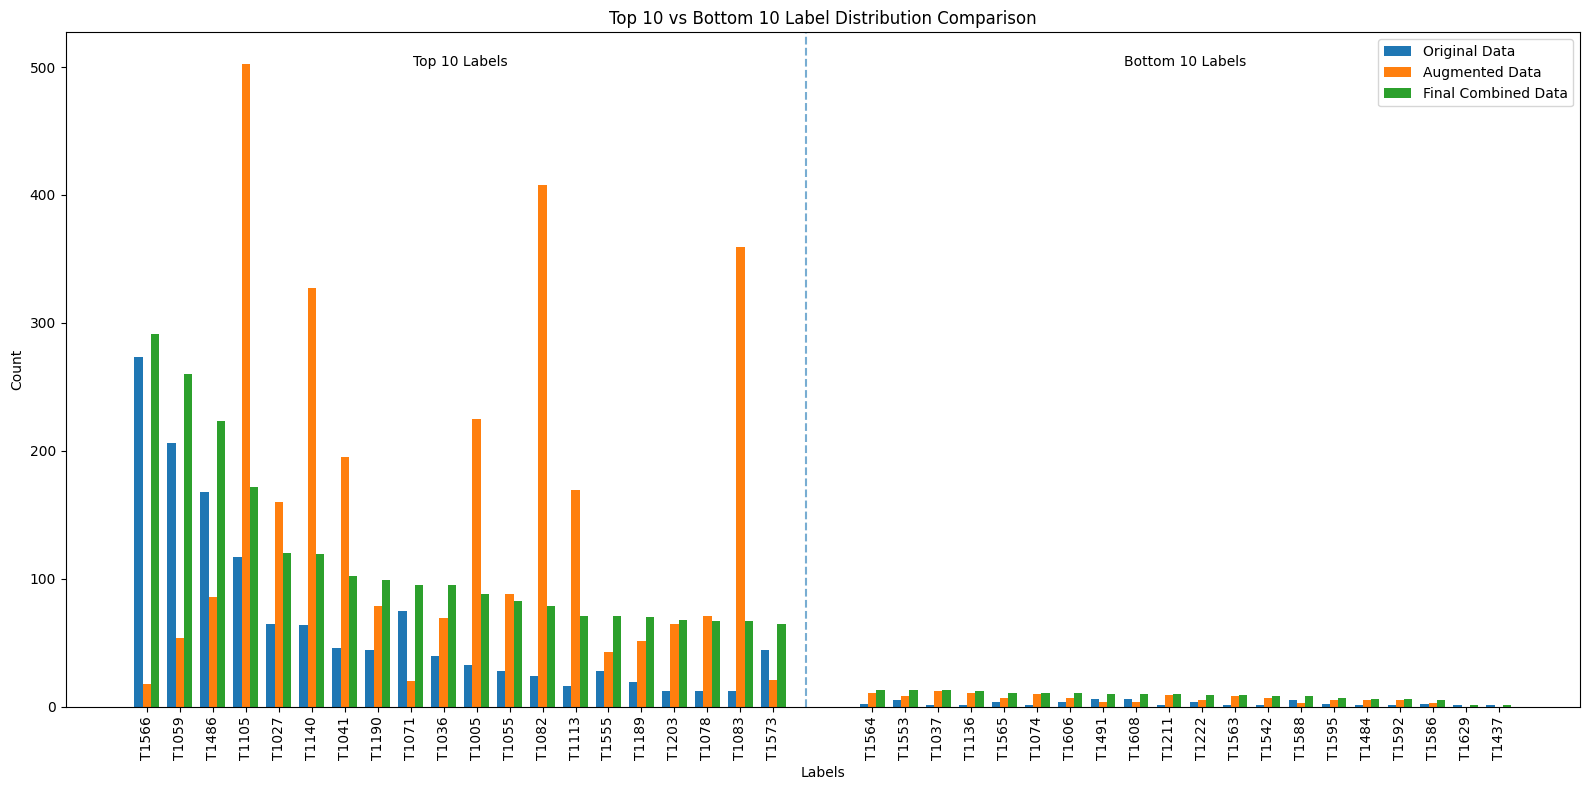

In [43]:
import matplotlib.pyplot as plt

sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]

# Split the labels into the top 10 and the last 10 labels
top_10_labels = sorted_final_labels_labels[:20]
bottom_10_labels = sorted_final_labels_labels[-20:]

# Extract counts for the top 10 labels
top_10_counts_data1 = [label_counts_data1.get(label, 0) for label in top_10_labels]
top_10_counts_data2 = [label_counts_data2.get(label, 0) for label in top_10_labels]
top_10_counts_final = [final_label_counts.get(label, 0) for label in top_10_labels]

# Extract counts for the bottom 10 labels
bottom_10_counts_data1 = [label_counts_data1.get(label, 0) for label in bottom_10_labels]
bottom_10_counts_data2 = [label_counts_data2.get(label, 0) for label in bottom_10_labels]
bottom_10_counts_final = [final_label_counts.get(label, 0) for label in bottom_10_labels]

# Parameters
bar_width = 0.25
gap_size = 2  # space between top and bottom groups

# Combine labels
combined_labels = top_10_labels + bottom_10_labels

# Build x positions with a gap
top_positions = list(range(len(top_10_labels)))
bottom_positions = [i + len(top_10_labels) + gap_size for i in range(len(bottom_10_labels))]
positions = top_positions + bottom_positions

# Combine counts
counts_data1 = top_10_counts_data1 + bottom_10_counts_data1
counts_data2 = top_10_counts_data2 + bottom_10_counts_data2
counts_final = top_10_counts_final + bottom_10_counts_final

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(positions, counts_data1, bar_width, label="Original Data")
ax.bar([p + bar_width for p in positions], counts_data2, bar_width, label="Augmented Data")
ax.bar([p + 2 * bar_width for p in positions], counts_final, bar_width, label="Final Combined Data")

# X-axis ticks
ax.set_xticks([p + bar_width for p in positions])
ax.set_xticklabels(combined_labels, rotation=90)

# Labels & title
ax.set_ylabel("Count")
ax.set_xlabel("Labels")
ax.set_title("Top 10 vs Bottom 10 Label Distribution Comparison")

# Visual separator line between groups
separator_x = top_positions[-1] + gap_size / 2
ax.axvline(separator_x + bar_width, linestyle="--", alpha=0.6)

# Annotations (use current ylim after plotting)
ymax = ax.get_ylim()[1]
ax.text(sum(top_positions) / len(top_positions) + bar_width, ymax * 0.95, "Top 10 Labels", ha="center")
ax.text(sum(bottom_positions) / len(bottom_positions) + bar_width, ymax * 0.95, "Bottom 10 Labels", ha="center")

ax.legend()
plt.tight_layout()
plt.show()

Performance driven

In [16]:
#/home/simonettos/thijs/classification/classification/extra/all_docs_cm.csv
import pandas as pd
cm_all_df = pd.read_csv('/home/simonettos/thijs/classification/classification/extra/all_docs_cm.csv')
print(cm_all_df.head())

                                                 doc      label  TP  FP  FN  \
0  3CXDesktopApp Backdoored in a Suspected Lazaru...  T1003.001   0   0   0   
1  3CXDesktopApp Backdoored in a Suspected Lazaru...      T1005   0   0   1   
2  3CXDesktopApp Backdoored in a Suspected Lazaru...      T1012   0   0   0   
3  3CXDesktopApp Backdoored in a Suspected Lazaru...      T1016   0   0   0   
4  3CXDesktopApp Backdoored in a Suspected Lazaru...  T1021.001   0   0   0   

   TN  
0   1  
1   0  
2   1  
3   1  
4   1  


In [18]:
sum_per_label = (
    cm_all_df
    .groupby("label")[["TP","FP","FN","TN"]]
    .sum()
    .reset_index()
)
avg_per_label = (
    cm_all_df
    .groupby("label")[["TP","FP","FN","TN"]]
    .mean()
    .reset_index()
)

sum_per_label["precision"] = sum_per_label["TP"] / (sum_per_label["TP"] + sum_per_label["FP"] + 1e-12)
sum_per_label["recall"]    = sum_per_label["TP"] / (sum_per_label["TP"] + sum_per_label["FN"] + 1e-12)


In [20]:
print("Sum per label:")
print(sum_per_label.head())

print("Avg per label:")
print(avg_per_label.head())

Sum per label:
       label  TP  FP  FN  TN  precision    recall
0  T1003.001   9   0   0  22        1.0  1.000000
1      T1005   0   0  10  21        0.0  0.000000
2      T1012   0   0   3  28        0.0  0.000000
3      T1016   1   0   4  26        1.0  0.200000
4  T1021.001   8   0   1  22        1.0  0.888889
Avg per label:
       label        TP   FP        FN        TN
0  T1003.001  0.290323  0.0  0.000000  0.709677
1      T1005  0.000000  0.0  0.322581  0.677419
2      T1012  0.000000  0.0  0.096774  0.903226
3      T1016  0.032258  0.0  0.129032  0.838710
4  T1021.001  0.258065  0.0  0.032258  0.709677


Global augmentation

TRAM

In [17]:



data1 = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/tram_train.json")
data2 = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/tram_train_augmented_mitre.json")

data1 = ensure_labels_column(data1)
data2 = ensure_labels_column(data2)

aug_df = pd.concat([data1, data2]) 
print("Original rows:", len(data1))
print("Augmented rows:", len(aug_df))
print("Added rows:", len(aug_df) - len(data1))
print("augmented examples:\n", aug_df.tail(20))
print("Augmented rows:", len(aug_df))
print("Percentage of augmented data:", (len(aug_df) - len(data1)) / len(data1) * 100, "%")

# --- Make sure labels are filtered in each DF ---
data1_filtered = data1.copy()
data1_filtered["labels"] = data1_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

data2_filtered = data2.copy()
data2_filtered["labels"] = data2_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Your concatenated/augmented DF (use whatever you named it) ---
# Example: aug_df is the final combined dataset after you appended sampled rows
aug_df_filtered = aug_df.copy()
aug_df_filtered["labels"] = aug_df_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Counters used by the plot ---
label_counts_data1 = count_labels_from_df(data1_filtered)
label_counts_data2 = count_labels_from_df(data2_filtered)
final_label_counts  = count_labels_from_df(aug_df_filtered)

# Sorted labels based on FINAL distribution
sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]
print ("Original label counter:", label_counts_data1)
print ("Augmented label counter:", label_counts_data2)
print ("Final label counter:", final_label_counts)
print(len(label_counts_data1))
print(len(label_counts_data2))
#labels not in the augmentation dataset but in the original
labels_not_in_aug = [lbl for lbl in label_counts_data1 if lbl not in label_counts_data2]
print("Labels in original but not in augmented:", labels_not_in_aug)


Original rows: 15358
Augmented rows: 23287
Added rows: 7929
augmented examples:
                                                sentence       labels  \
7909  xCmd can be used to execute binaries on remote...  [T1569.002]   
7910  yty collects files with the following extensio...      [T1005]   
7911    yty collects screenshots of the victim machine.      [T1113]   
7912                yty collects the victim’s username.      [T1033]   
7913  yty establishes persistence by creating a sche...  [T1053.005]   
7914  yty gathers information on victim’s drives and...      [T1083]   
7915  yty gathers the computer name, CPU information...      [T1082]   
7916  yty gets an output of running processes using ...      [T1057]   
7917  yty runs <code>ipconfig /all</code> and collec...      [T1016]   
7918  yty uses a keylogger plugin to gather keystrokes.  [T1056.001]   
7919                zwShell can browse the file system.      [T1083]   
7920            zwShell can launch command-line shells.

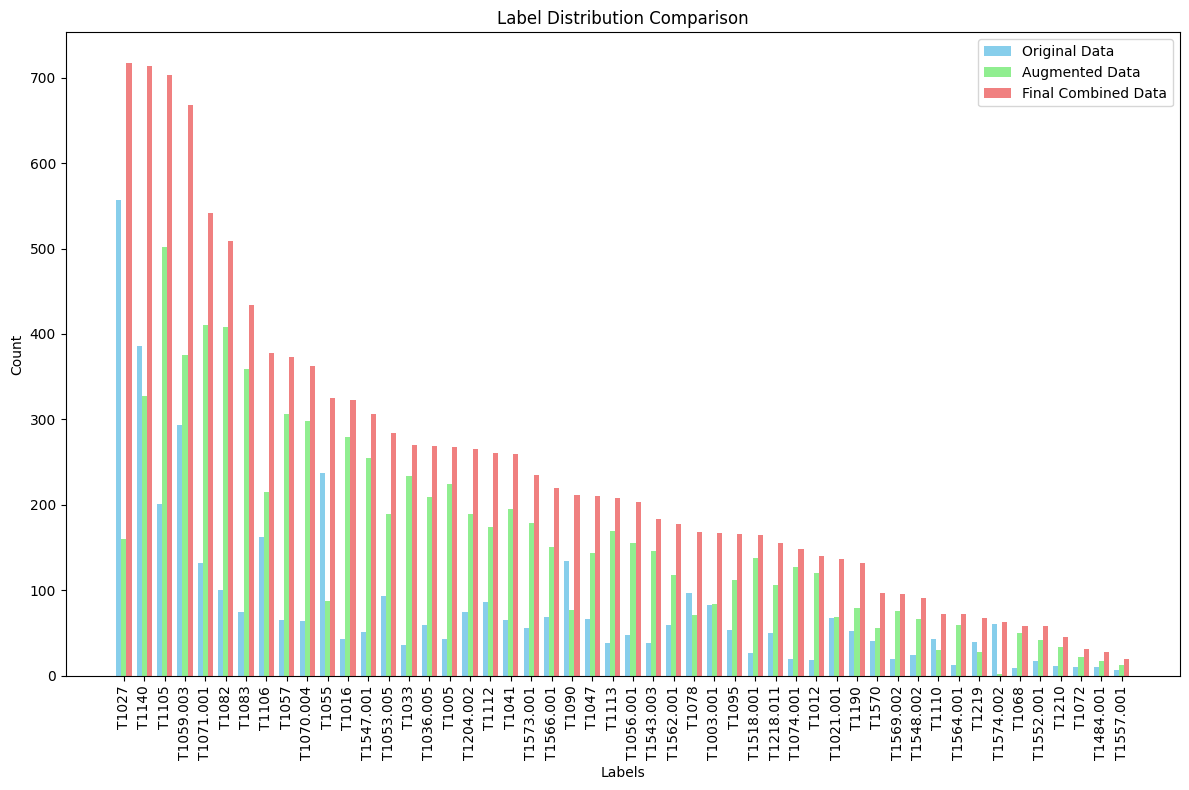

In [18]:


sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]

# Split the labels into the top 10 and the last 10 labels
top_10_labels = sorted_final_labels_labels[:10]
bottom_10_labels = sorted_final_labels_labels[-10:]

sorted_labels_labels = [item for item in sorted_final_labels_labels]
sorted_counts_data1 = [label_counts_data1.get(label, 0) for label in sorted_final_labels_labels]
sorted_counts_data2 = [label_counts_data2.get(label, 0) for label in sorted_final_labels_labels]
sorted_counts_final = [final_label_counts.get(label, 0) for label in sorted_final_labels_labels]

# Create subplots to compare the distributions (vertical bars)
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.25  # Width of the bars
index = range(len(sorted_labels_labels))  # Position of the bars

ax.bar(index, sorted_counts_data1, bar_width, label='Original Data', color='skyblue')
ax.bar([i + bar_width for i in index], sorted_counts_data2, bar_width, label='Augmented Data', color='lightgreen')
ax.bar([i + 2 * bar_width for i in index], sorted_counts_final, bar_width, label='Final Combined Data', color='lightcoral')

ax.set_ylabel('Count')
ax.set_xlabel('Labels')
ax.set_title('Label Distribution Comparison')
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(sorted_labels_labels, rotation=90)  # Rotate labels for better readability
ax.legend()

plt.tight_layout()
plt.show()



In [21]:



data1 = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/bosch_train.json")
data2 = pd.read_json("/home/simonettos/thijs/classification/classification/datasets/bosch_train_augmented_mitre.json")

data1 = ensure_labels_column(data1)
data2 = ensure_labels_column(data2)

aug_df = pd.concat([data1, data2]) 
print("Original rows:", len(data1))
print("Augmented rows:", len(aug_df))
print("Added rows:", len(aug_df) - len(data1))
print("augmented examples:\n", aug_df.tail(20))
print("Augmented rows:", len(aug_df))
print("Percentage of augmented data:", (len(aug_df) - len(data1)) / len(data1) * 100, "%")

# --- Make sure labels are filtered in each DF ---
data1_filtered = data1.copy()
data1_filtered["labels"] = data1_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

data2_filtered = data2.copy()
data2_filtered["labels"] = data2_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Your concatenated/augmented DF (use whatever you named it) ---
# Example: aug_df is the final combined dataset after you appended sampled rows
aug_df_filtered = aug_df.copy()
aug_df_filtered["labels"] = aug_df_filtered["labels"].apply(lambda x: filter_labels_list(x, PREFIXES))

# --- Counters used by the plot ---
label_counts_data1 = count_labels_from_df(data1_filtered)
label_counts_data2 = count_labels_from_df(data2_filtered)
final_label_counts  = count_labels_from_df(aug_df_filtered)

# Sorted labels based on FINAL distribution
sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]
print ("Original label counter:", label_counts_data1)
print ("Augmented label counter:", label_counts_data2)
print ("Final label counter:", final_label_counts)
print(len(label_counts_data1))
print(len(label_counts_data2))
#labels not in the augmentation dataset but in the original
labels_not_in_aug = [lbl for lbl in label_counts_data1 if lbl not in label_counts_data2]
print("Labels in original but not in augmented:", labels_not_in_aug)


Original rows: 3668
Augmented rows: 10203
Added rows: 6535
augmented examples:
                                                sentence   labels entities  \
6515  route can be used to discover routing configur...  [T1016]      NaN   
6516  sqlmap can be used to automate exploitation of...  [T1190]      NaN   
6517  xCaon has a command to download files to the v...  [T1105]      NaN   
6518  xCaon has added persistence via the Registry k...  [T1547]      NaN   
6519  xCaon has decoded strings from the C2 server b...  [T1140]      NaN   
6520   xCaon has uploaded files from victims' machines.  [T1005]      NaN   
6521  xCaon has used the GetAdaptersInfo() API call ...  [T1016]      NaN   
6522  yty collects files with the following extensio...  [T1005]      NaN   
6523    yty collects screenshots of the victim machine.  [T1113]      NaN   
6524                yty collects the victim’s username.  [T1033]      NaN   
6525  yty gathers information on victim’s drives and...  [T1083]      NaN

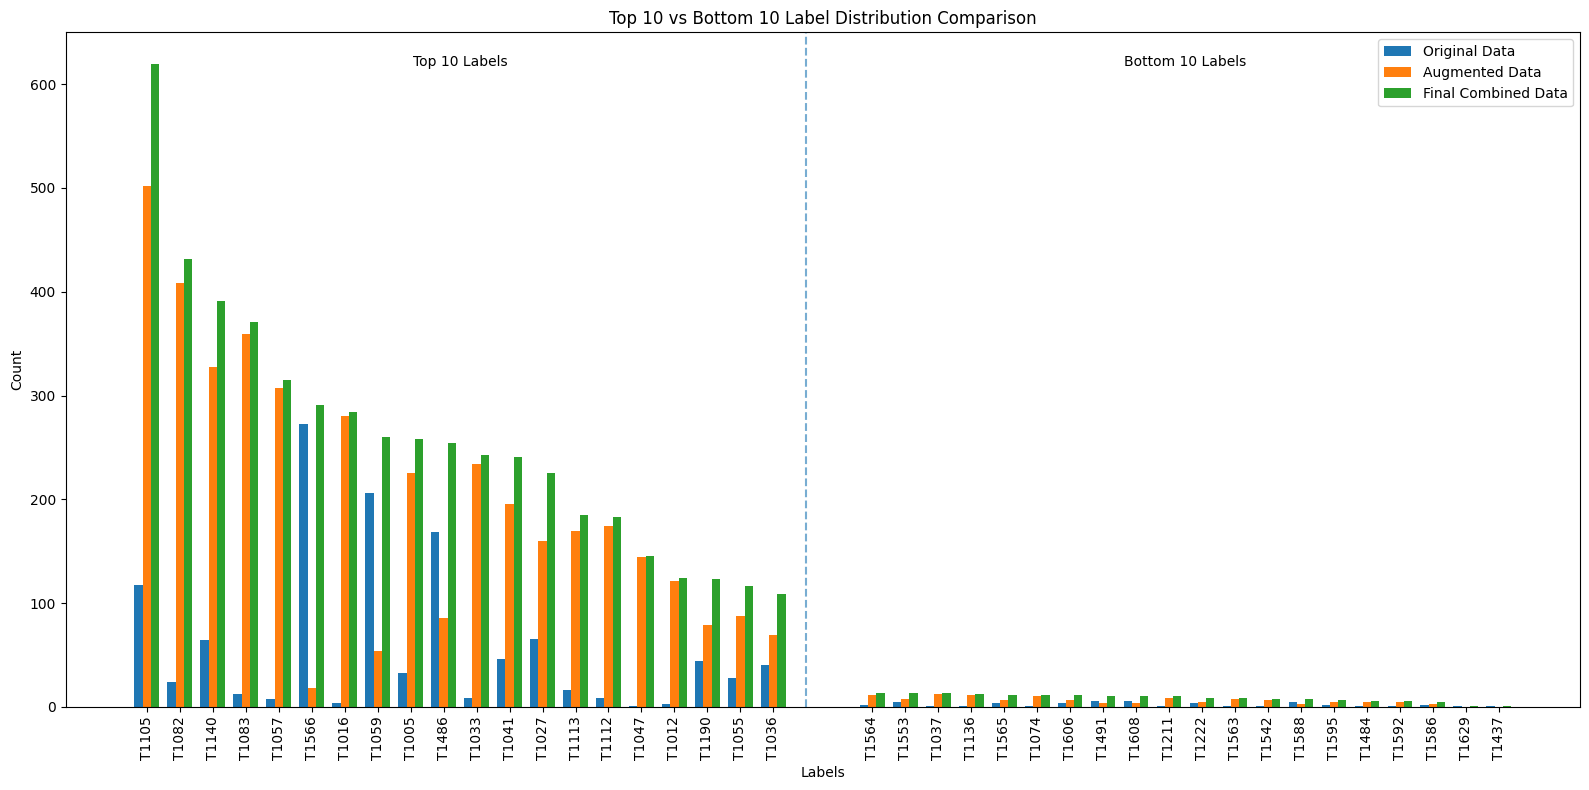

In [20]:
import matplotlib.pyplot as plt

sorted_final_labels_labels = [lbl for lbl, _ in final_label_counts.most_common()]

# Split the labels into the top 10 and the last 10 labels
top_10_labels = sorted_final_labels_labels[:20]
bottom_10_labels = sorted_final_labels_labels[-20:]

# Extract counts for the top 10 labels
top_10_counts_data1 = [label_counts_data1.get(label, 0) for label in top_10_labels]
top_10_counts_data2 = [label_counts_data2.get(label, 0) for label in top_10_labels]
top_10_counts_final = [final_label_counts.get(label, 0) for label in top_10_labels]

# Extract counts for the bottom 10 labels
bottom_10_counts_data1 = [label_counts_data1.get(label, 0) for label in bottom_10_labels]
bottom_10_counts_data2 = [label_counts_data2.get(label, 0) for label in bottom_10_labels]
bottom_10_counts_final = [final_label_counts.get(label, 0) for label in bottom_10_labels]

# Parameters
bar_width = 0.25
gap_size = 2  # space between top and bottom groups

# Combine labels
combined_labels = top_10_labels + bottom_10_labels

# Build x positions with a gap
top_positions = list(range(len(top_10_labels)))
bottom_positions = [i + len(top_10_labels) + gap_size for i in range(len(bottom_10_labels))]
positions = top_positions + bottom_positions

# Combine counts
counts_data1 = top_10_counts_data1 + bottom_10_counts_data1
counts_data2 = top_10_counts_data2 + bottom_10_counts_data2
counts_final = top_10_counts_final + bottom_10_counts_final

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(positions, counts_data1, bar_width, label="Original Data")
ax.bar([p + bar_width for p in positions], counts_data2, bar_width, label="Augmented Data")
ax.bar([p + 2 * bar_width for p in positions], counts_final, bar_width, label="Final Combined Data")

# X-axis ticks
ax.set_xticks([p + bar_width for p in positions])
ax.set_xticklabels(combined_labels, rotation=90)

# Labels & title
ax.set_ylabel("Count")
ax.set_xlabel("Labels")
ax.set_title("Top 10 vs Bottom 10 Label Distribution Comparison")

# Visual separator line between groups
separator_x = top_positions[-1] + gap_size / 2
ax.axvline(separator_x + bar_width, linestyle="--", alpha=0.6)

# Annotations (use current ylim after plotting)
ymax = ax.get_ylim()[1]
ax.text(sum(top_positions) / len(top_positions) + bar_width, ymax * 0.95, "Top 10 Labels", ha="center")
ax.text(sum(bottom_positions) / len(bottom_positions) + bar_width, ymax * 0.95, "Bottom 10 Labels", ha="center")

ax.legend()
plt.tight_layout()
plt.show()

Measure labels in ALL siamese-biencoder

In [121]:
import json

with open("/home/simonettos/thijs/data_augmentatio_stefano/siamese_unsup_sup/test_clean.json", "r", encoding="utf-8") as f:
    data = json.load(f)

unique_labels = {
    label
    for item in data
    for label in item.get("labels", [])
}

print("Number of different labels:", len(unique_labels))
print("Labels:", sorted(unique_labels))

Number of different labels: 480
Labels: ['T10', 'T1001', 'T1001.001', 'T1001.002', 'T1001.003', 'T1003', 'T1003.001', 'T1003.002', 'T1003.003', 'T1003.004', 'T1003.005', 'T1003.006', 'T1003.008', 'T1005', 'T1007', 'T1008', 'T1010', 'T1012', 'T1013', 'T1014', 'T1016', 'T1017', 'T1018', 'T1019', 'T1020', 'T1020.001', 'T1021.001', 'T1021.002', 'T1021.004', 'T1021.005', 'T1021.006', 'T1022', 'T1025', 'T1027', 'T1027.001', 'T1027.002', 'T1027.003', 'T1027.006', 'T1027.007', 'T1027.009', 'T1027.010', 'T1027.011', 'T1027.012', 'T1027.013', 'T1027.015', 'T1027.016', 'T1030', 'T1033', 'T1036', 'T1036.001', 'T1036.002', 'T1036.003', 'T1036.004', 'T1036.005', 'T1036.006', 'T1036.007', 'T1036.008', 'T1036.010', 'T1036.011', 'T1037', 'T1037.001', 'T1037.004', 'T1040', 'T1041', 'T1046', 'T1047', 'T1048', 'T1048.001', 'T1048.002', 'T1048.003', 'T1049', 'T1052', 'T1052.001', 'T1053', 'T1053.002', 'T1053.003', 'T1053.005', 'T1053.007', 'T1054', 'T1055', 'T1055.001', 'T1055.002', 'T1055.004', 'T1055.005